In [61]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.io import ascii
from scipy.signal import find_peaks
from matplotlib.ticker import MaxNLocator, AutoMinorLocator
from scipy.optimize import curve_fit
from astropy import constants as const
from astropy import units as u


In [62]:
#---- Velocities Corrections ----#

vel_corr_IRAS_06531 = 39e0
vel_corr_IRAS_07145 = 88e0
vel_corr_IRAS_07180 = 58e0
vel_corr_IRAS_08500 = 58e0
vel_corr_R_Hor = 38e0
vel_corr_RV_Aqr = 2e0
vel_corr_RZ_Sgr = -29.5e0
vel_corr_UU_For = -7e0
vel_corr_V510_Pup = 45e0

#Nota preguntar si aplico esto antes de transformar a velocidades o despues#


In [63]:
sources = {
    'IRAS_06531_115': r"C:\Users\pablo\OneDrive\Escritorio\Trabajo con Luciano\Working folder\Carta_data\IRAS_06531-0216\member.uid___A001_X13d5_X127.iras_06531-0216_sci.spw22.cube.I.pbcor.fits-Z-profile-Region_1-Statistic_FluxDensity-Coordinate_Current-2026-04-05-17-37-08.tsv",
    'IRAS_06531_231': r"C:\Users\pablo\OneDrive\Escritorio\Trabajo con Luciano\Working folder\Carta_data\IRAS_06531-0216\member.uid___A001_X143a_X35.iras_06531-0216_sci.spw20.cube.I.pbcor.fits-Z-profile-Region_1-Statistic_FluxDensity-Coordinate_Current-2026-04-05-17-44-02.tsv",
    'IRAS_06531_220': r"C:\Users\pablo\OneDrive\Escritorio\Trabajo con Luciano\Working folder\Carta_data\IRAS_06531-0216\member.uid___A001_X143a_X42.iras_06531-0216_sci.spw16.cube.I.pbcor.fits-Z-profile-Region_1-Statistic_FluxDensity-Coordinate_Current-2026-04-19-21-20-39.tsv"
}

data = {}
for name, path in sources.items():
    # loop para acceder a la data con ascii y cambiar a GHz como se trabajo en el paper
    table = ascii.read(
    path,
    names=['col1', 'col2'],   # nombres que quieras asignarle
    comment='#',                      # ignora todas las líneas con #
    delimiter='\t'                    # separador es tabulación
    )
    data[name] = table


for name, table in data.items():
    # loop para acceder a la data por nombre de source
    globals()[name] = table

## Nota Distancia en base a las coor galact5ic se pueddde establcer a que hgalaxia pertenece y talvez ahi se puede estimar una distancia
## 


MI OBJETIVO ES PODER CALCULAR EL MASS LOSS RATE DE LOS TARGETS, PARA ELLO SE USA EN EL CASO DE OPTICAMENTE DELGADO $ \Huge \dot{M} = 4.55×10^{-19}\left\lceil \frac{T_{mb}}{Log(W/0.04)s(J))}  \right\rceil ^{5/6} f_{CO}^{-1} V_{exp}^{11/6} (D\theta)^{5/3}$

Y EN EL CASO PARA OPTICAMENTE GRUESO

$\Huge  \dot{M}= 1.4 \frac{T_{mb}V_e^{2}D^{2}\theta^{2}}{2×10^{19} f_{CO}^{0.85} s(J)}$


-- IRAS_06531-0216 --

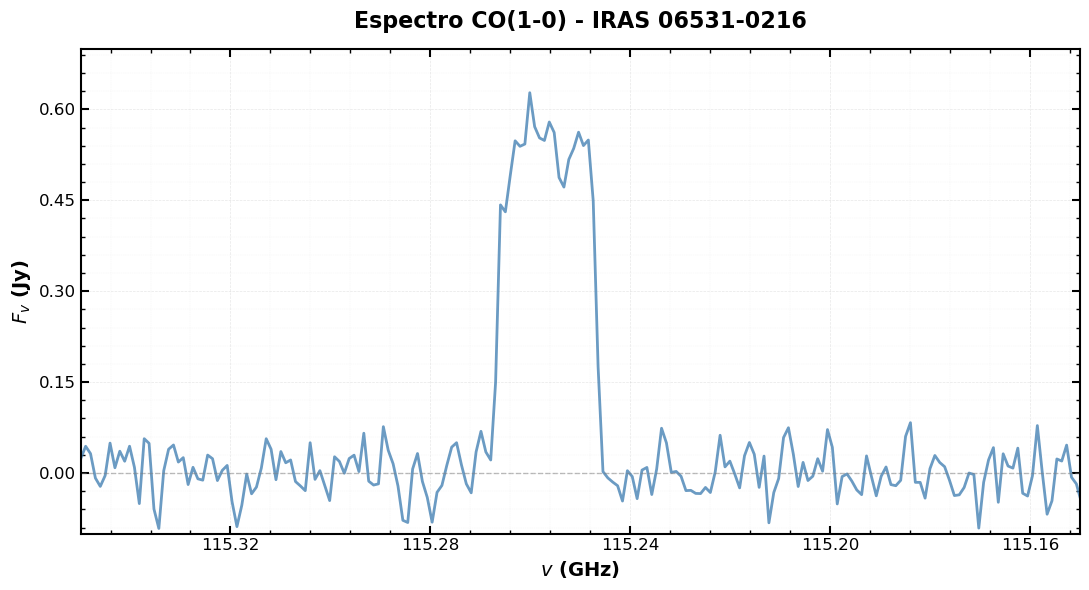

In [64]:
## Línea CO(1-0) - IRAS 06531 ##COUNT 1
lim_CO_1to0_IRAS_06531_115 = (115.350, 115.150)

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(IRAS_06531_115["col1"], IRAS_06531_115["col2"], 
        linewidth=2, color='steelblue', alpha=0.8)

ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel(r'$v$ (GHz)', fontsize=14, fontweight='bold')
ax.set_ylabel(r'$F_v$ (Jy)', fontsize=14, fontweight='bold')
ax.set_title('Espectro CO(1-0) - IRAS 06531-0216', 
             fontsize=16, fontweight='bold', pad=15)

ax.set_xlim(lim_CO_1to0_IRAS_06531_115)
ax.set_ylim(-0.1, 0.7)

ax.xaxis.set_major_locator(MaxNLocator(6))
ax.yaxis.set_major_locator(MaxNLocator(6))
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.grid(True, which='major', alpha=0.3, linestyle='--', linewidth=0.5)
ax.grid(True, which='minor', alpha=0.15, linestyle='--', linewidth=0.3)

ax.tick_params(axis='both', which='major', labelsize=12, 
               direction='in', length=6, width=1.5, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', 
               length=3, width=1, top=True, right=True)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()

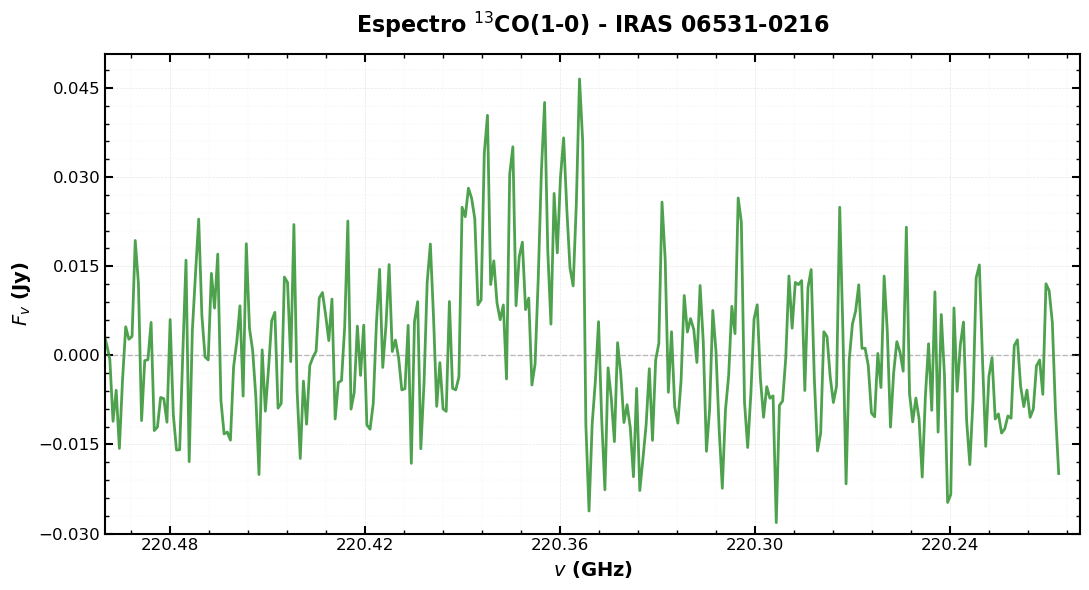

In [65]:
## Línea ^13CO(1-0) - IRAS 06531 ## COUNT 1
lim_CO_2to1_IRAS_06531_220 = (220.5, 220.2)

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(IRAS_06531_220["col1"], IRAS_06531_220["col2"], 
        linewidth=2, color='forestgreen', alpha=0.8)

ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

ax.set_xlabel(r'$v$ (GHz)', fontsize=14, fontweight='bold')
ax.set_ylabel(r'$F_{v}$ (Jy)', fontsize=14, fontweight='bold')

ax.set_title(r'Espectro $^{13}$CO(1-0) - IRAS 06531-0216', 
             fontsize=16, fontweight='bold', pad=15)

ax.set_xlim(lim_CO_2to1_IRAS_06531_220)
ax.set_ylim(-0.03, 5.0712060322e-2)

ax.xaxis.set_major_locator(MaxNLocator(6))
ax.yaxis.set_major_locator(MaxNLocator(6))
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.grid(True, which='major', alpha=0.3, linestyle='--', linewidth=0.5)
ax.grid(True, which='minor', alpha=0.15, linestyle='--', linewidth=0.3)

ax.tick_params(axis='both', which='major', labelsize=12, 
               direction='in', length=6, width=1.5, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', 
               length=3, width=1, top=True, right=True)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()

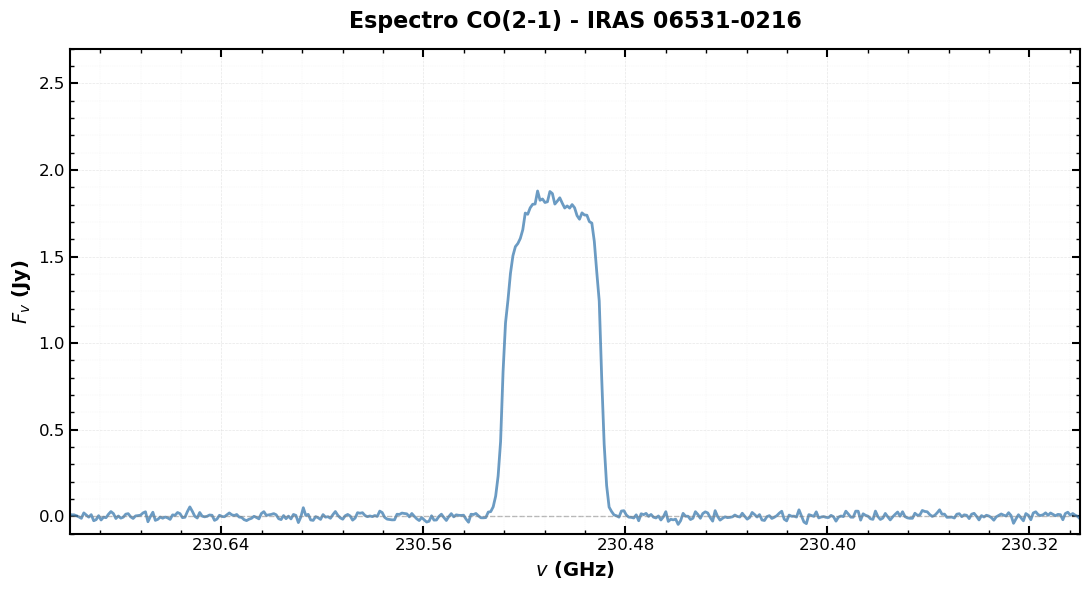

In [66]:
## Línea CO(2-1) - IRAS 06531 ## COUNT 1
lim_CO_2to1_IRAS_06531_231 = (230.70, 230.30)

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(IRAS_06531_231["col1"], IRAS_06531_231["col2"], 
        linewidth=2, color='steelblue', alpha=0.8)

ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

ax.set_xlabel(r'$v$ (GHz)', fontsize=14, fontweight='bold')
ax.set_ylabel(r'$F_{v}$ (Jy)', fontsize=14, fontweight='bold')

ax.set_title('Espectro CO(2-1) - IRAS 06531-0216', 
             fontsize=16, fontweight='bold', pad=15)

ax.set_xlim(lim_CO_2to1_IRAS_06531_231)
ax.set_ylim(-0.1, 2.7)

ax.xaxis.set_major_locator(MaxNLocator(6))
ax.yaxis.set_major_locator(MaxNLocator(6))
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.grid(True, which='major', alpha=0.3, linestyle='--', linewidth=0.5)
ax.grid(True, which='minor', alpha=0.15, linestyle='--', linewidth=0.3)

ax.tick_params(axis='both', which='major', labelsize=12, 
               direction='in', length=6, width=1.5, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', 
               length=3, width=1, top=True, right=True)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()

In [67]:
## NOTA: EL ISOTOPO 13CO(2-1) SE REPITE EN EL PAPER 

In [68]:
## NOTA: TAMBIEN SE REPITE EL COUNT 1 DE CO(2-1) 

PARA EL CALCULO DE $\Huge T_{mb}$ es $T_{mb}(v) = T_{mb}^{peak} \left[ 1 - \left( \frac{V -V_c}{V_e} \right)^{2} \right] , \left| V- V_c \right| < V_e$

DONDE LO PRINCIPAL ES PODER OBTENER EL VALOR DE $\Huge T_{mb}^{peak}$ con $\Huge T_{mb}^{peak}  = T_A^{\star} \frac {F_{eff}}{B_eff}$ PERO !TENGO DUDA! PUESTO QUE EL PAPER CALCULA ESTO PARA TELESCOPIO DE DISCO UNICO Y TRABAJAMOS CON UN ARRAY DE TELESCOPIOS ES POR ESTO QUE POR EL MOMENTO, CALCULO EL $\Huge T_{mb}$ CON $\Huge 1.222 × 10^3 \frac{I}{v^2 \theta_{maj} \theta_{min} } $ formula obtenida referenciando el artifulo de $Flux\: Density - Brightness\: Temperature\: Conversion\: By\: NRAO$ 

In [69]:
def find_peaks_in_range(data, x_limits, **peak_kwargs):

    x_max, x_min = x_limits 
    
    x = data["col1"]
    y = data["col2"]
    
    mask = (x >= x_min) & (x <= x_max)
    solo_true = [x for x in mask if x]
    
    indices_in_range = np.where(mask)[0]
    if len(indices_in_range) == 0:
        print(f"ERRRROR")
        return {
            'x_peaks': np.array([]),
            'y_peaks': np.array([]),
            'indices': np.array([]),
            'properties': {}
        }
    
    start_idx = indices_in_range[0]
    end_idx = indices_in_range[-1]

    peaks, properties = find_peaks(y[start_idx:end_idx+1], **peak_kwargs)
    
    peaks_original = peaks + start_idx
    
    x_peaks = x[peaks_original]
    y_peaks = y[peaks_original]
    
    return {
        'x_peaks': x_peaks,
        'y_peaks': y_peaks,
        'indices': peaks_original,
        'properties': properties
    }


#result1 = find_peaks_in_range(IRAS_06531, lim_CO_1to0_IRAS_06531, height=0.5, prominence=0.1) ## prueba si funciona esta funcion para encontrar peak


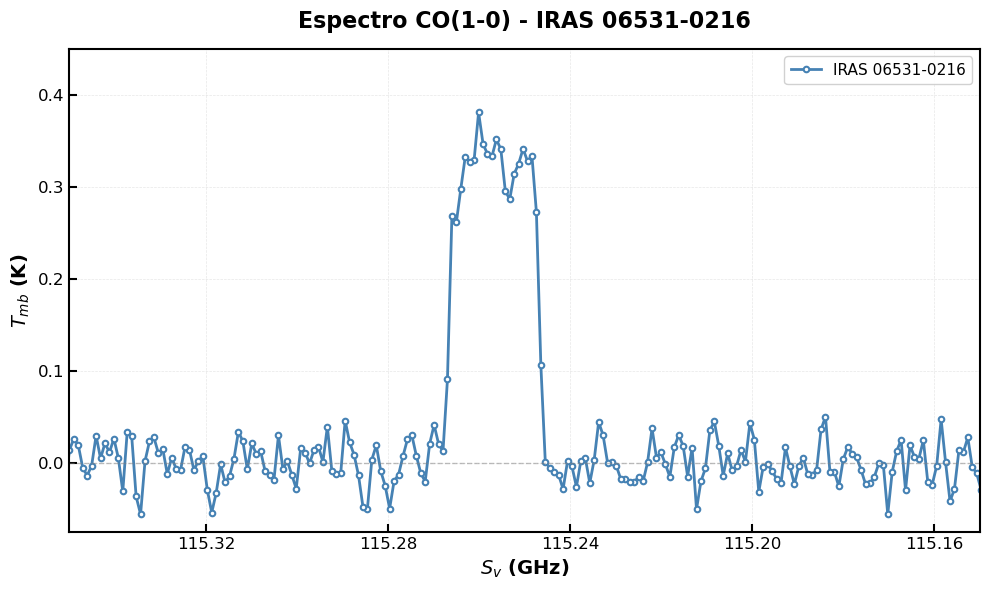

In [70]:
def convert_T_mb(data, limit):
    # Beam en arcsec -> convertir a radianes
    theta_maj_arcsec = (4.972155506402E-03) * 3600
    theta_min_arcsec = (2.351931261700E-03) * 3600
    
    arcsec_to_rad = np.pi / (180 * 3600)
    theta_maj = theta_maj_arcsec * arcsec_to_rad  # radianes
    theta_min = theta_min_arcsec * arcsec_to_rad  # radianes

    x = data["col1"]  # GHz
    y = data["col2"]  # Jy

    x_max, x_min = limit

    T_mb = 2.8725e-5 * (y / ((x**2) * theta_maj * theta_min))

    return {'col1': x, 'T_mb': T_mb}


T_mb_IRAS_06531 = convert_T_mb(IRAS_06531_115, lim_CO_1to0_IRAS_06531_115)


fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(T_mb_IRAS_06531["col1"], T_mb_IRAS_06531["T_mb"], 
        'o-', linewidth=2, markersize=4, color='steelblue', 
        markerfacecolor='white', markeredgewidth=1.5,
        label='IRAS 06531-0216')

ax.set_xlim(lim_CO_1to0_IRAS_06531_115)

ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

ax.set_xlabel(r'$S_v$ (GHz)', fontsize=14, fontweight='bold')
ax.set_ylabel(r'$T_{mb}$ (K)', fontsize=14, fontweight='bold')

ax.set_title('Espectro CO(1-0) - IRAS 06531-0216', 
             fontsize=16, fontweight='bold', pad=15)

ax.set_xlim(lim_CO_1to0_IRAS_06531_115)
ax.set_ylim(-0.075, 0.45)
ax.xaxis.set_major_locator(MaxNLocator(6))
ax.yaxis.set_major_locator(MaxNLocator(6))
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.legend(loc='best', fontsize=11, framealpha=0.9)
ax.tick_params(axis='both', which='major', labelsize=12, 
               direction='in', length=6, width=1.5)
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=1)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()



In [71]:
from astropy import constants as const

def freq_to_velocity(freq, freq_rest, convention='radio'):
    """
    - CO(1-0): 115.271 GHz
    - CO(2-1): 230.538 GHz
    - CO(3-2): 345.796 GHz

    """
    c = const.c.to('km/s').value  # Velocidad de la luz en km/s
    
    if convention == 'radio':
        # Definicion radio (la mas usada en radioastronomia)
        velocity = c * (freq_rest - freq) / freq_rest

    else:
        raise ValueError("Revisar eeeee")
    
    return velocity


def convert_data_to_velocity(data, freq_rest, convention='radio'):

    from copy import deepcopy
    
    data_vel = deepcopy(data)
    
    # Convertir frecuencia a velocidad
    freq_ghz = np.array(data_vel["col1"])
    velocity = freq_to_velocity(freq_ghz, freq_rest, convention)
    
    # Reemplazar col1 con velocidad
    data_vel["col1"] = velocity
    
    return data_vel


# Frecuencia de reposo de CO(1-0)
freq_rest_CO10 = 115.271  # GHz

data_vel = {}
for name, table in data.items():
    data_vel[name] = convert_data_to_velocity(table, freq_rest_CO10, convention='radio')


Parametros iniciales:
  T_peak ~ 0.381 K
  V_c    ~ 28.332 km/s
  V_e    ~ 24.130 km/s
  beta   ~ 0.40

RESULTADOS DEL AJUSTE:
T_mb^peak = 0.338 ± 0.007 K
V_c       = 37.222  ± 0.001 km/s
V_e       = 26.671  ± 0.001 km/s
R^2       = 0.9517


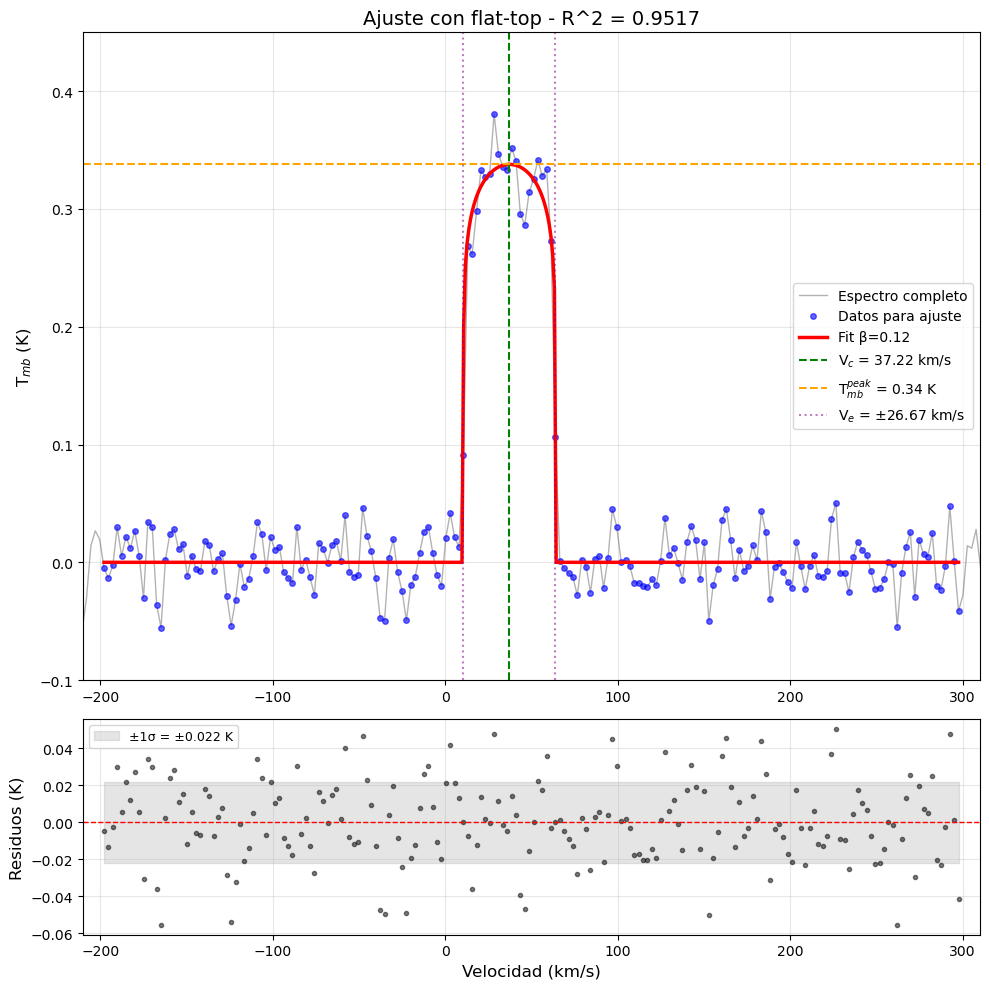

In [72]:
def flat_top_profile(v, T_peak, V_c, V_e, beta):
    
    term = ((v - V_c) / V_e)**2
    result = np.zeros_like(v, dtype=float)
    mask = term <= 1
    result[mask] = T_peak * (1 - term[mask])**beta
    return result


def fit_line_profile(data, data_1, v_limits, plot=True):

    v_min, v_max = v_limits
    
    v = np.array(data["col1"])
    T_mb_IRAS_06531 = convert_T_mb(data_1, lim_CO_1to0_IRAS_06531_115)
    T_mb = T_mb_IRAS_06531["T_mb"]
    
    mask = (v >= v_min) & (v <= v_max)
    v_fit = v[mask]
    T_fit = T_mb[mask]
    
    T_peak_guess = np.max(T_fit)
    idx_max = np.argmax(T_fit)
    V_c_guess = v_fit[idx_max]
    
    half_max = T_peak_guess / 2
    above_half = T_fit > half_max
    if np.sum(above_half) > 1:
        v_half_range = v_fit[above_half]
        V_e_guess = (v_half_range.max() - v_half_range.min()) / 2
    else:
        V_e_guess = (v_max - v_min) / 4
    
    V_e_guess = max(abs(V_e_guess), 1.0)
    beta_guess = 0.4  # <-- empieza con techo plano, la parabola clasica es 1.0
    
    p0 = [T_peak_guess, V_c_guess, V_e_guess, beta_guess]
    
    bounds = (
        [0,           v_min, 1,   0.1],   # beta minimo 0.1
        [T_peak_guess*2, v_max, (v_max-v_min), 2.0]  # beta maximo 2.0
    )
    
    print(f"Parametros iniciales:")
    print(f"  T_peak ~ {T_peak_guess:.3f} K")
    print(f"  V_c    ~ {V_c_guess:.3f} km/s")
    print(f"  V_e    ~ {V_e_guess:.3f} km/s")
    print(f"  beta   ~ {beta_guess:.2f}")
    
    try:
        popt, pcov = curve_fit(
            flat_top_profile,
            v_fit,
            T_fit,
            p0=p0,
            bounds=bounds,
            maxfev=10000
        )
        
        T_peak_fit, V_c_fit, V_e_fit, beta_fit = popt
        perr = np.sqrt(np.diag(pcov))
        
        T_model_fit = flat_top_profile(v_fit, *popt)
        residuals = T_fit - T_model_fit
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((T_fit - np.mean(T_fit))**2)
        r_squared = 1 - (ss_res / ss_tot)
        
        print(f"\n{'='*50}")
        print(f"RESULTADOS DEL AJUSTE:")
        print(f"{'='*50}")
        print(f"T_mb^peak = {T_peak_fit:.3f} ± {perr[0]:.3f} K")
        print(f"V_c       = {V_c_fit:.3f}  ± {perr[1]:.3f} km/s")
        print(f"V_e       = {V_e_fit:.3f}  ± {perr[2]:.3f} km/s")
        print(f"R^2       = {r_squared:.4f}")
        print(f"{'='*50}")
        
        if plot:
            v_model = np.linspace(v_fit.min(), v_fit.max(), 500)
            T_model = flat_top_profile(v_model, *popt)
            
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10),
                                           gridspec_kw={'height_ratios': [3, 1]})

            ax1.plot(v, T_mb, 'k-', alpha=0.3, label='Espectro completo', linewidth=1)
            ax1.plot(v_fit, T_fit, 'bo', markersize=4, label='Datos para ajuste', alpha=0.6)
            ax1.plot(v_model, T_model, 'r-', linewidth=2.5,
                     label=f'Fit β={beta_fit:.2f}')

            ax1.axvline(V_c_fit, color='green', linestyle='--', linewidth=1.5,
                        label=f'V$_c$ = {V_c_fit:.2f} km/s')
            ax1.axhline(T_peak_fit, color='orange', linestyle='--', linewidth=1.5,
                        label=f'T$_{{mb}}^{{peak}}$ = {T_peak_fit:.2f} K')
            ax1.axvline(V_c_fit - V_e_fit, color='purple', linestyle=':', alpha=0.5, linewidth=1.5)
            ax1.axvline(V_c_fit + V_e_fit, color='purple', linestyle=':', alpha=0.5, linewidth=1.5,
                        label=f'V$_e$ = ±{V_e_fit:.2f} km/s')

            ax1.set_ylabel('T$_{mb}$ (K)', fontsize=12)
            ax1.set_title(f'Ajuste con flat-top - R^2 = {r_squared:.4f}', fontsize=14)
            ax1.legend(loc='best', fontsize=10)
            ax1.grid(True, alpha=0.3)
            ax1.set_xlim([v_min - 10, v_max + 10])
            ax1.set_ylim(-0.10, 0.45)

            ax2.plot(v_fit, residuals, 'ko', markersize=3, alpha=0.5)
            ax2.axhline(0, color='red', linestyle='--', linewidth=1)
            ax2.fill_between(v_fit, -np.std(residuals), np.std(residuals),
                             alpha=0.2, color='gray',
                             label=f'±1σ = ±{np.std(residuals):.3f} K')
            ax2.set_xlabel('Velocidad (km/s)', fontsize=12)
            ax2.set_ylabel('Residuos (K)', fontsize=12)
            ax2.legend(loc='best', fontsize=9)
            ax2.grid(True, alpha=0.3)
            ax2.set_xlim([v_min - 10, v_max + 10])

            plt.tight_layout()
            plt.show()

        return {
            'T_peak': T_peak_fit,
            'V_c': V_c_fit,
            'V_e': V_e_fit,
            'beta': beta_fit,
            'errors': perr,
            'r_squared': r_squared,
            'popt': popt,
            'pcov': pcov
        }

    except Exception as e:
        print(f"ERROR en el ajuste: {e}")
        return None

v_limits = (-200, 300)  # Aaustar esto donde se vean los limites en general se puede ver en el paper jeje
T_mb_fit = fit_line_profile(data_vel['IRAS_06531_115'], IRAS_06531_115 , v_limits, plot=True)

Siguiente paso es necesario obtener el factor $\Huge W$ se define como la relación entre el flujo emitido por tu objeto a 4.6 μm y el flujo que emitiría una estrella de referencia a la misma distancia. Aqui paso a paso para guiarse

1. Definicion de la estrella de deferencia ($\Huge F_{ref}$)Se calcula el flujo de un cuerpo negro idealizado a la misma distancia que el target.Parametros de la estrella de referencia:Radio ($\Huge R$): $\Huge 5 \times 10^{13} \text{ cm}$Temperatura ($\Huge T$): $\Huge 2000 \text{ K}$Longitud de onda ($\huge \lambda$): $\Huge 4.6 \mu m$ (Banda W2 de WISE)La fórmula del flujo observado a una distancia $d$ es:$$\Huge F_{\lambda, ref} = \frac{\pi R^2}{d^2} B_{\lambda}(T)$$Donde $\Huge B_{\lambda}(T)$ es la función de Planck:$$\Huge B_{\lambda}(T) = \frac{2hc^2}{\lambda^5} \frac{1}{e^{\frac{hc}{\lambda k_B T}} - 1}$$


3. Cálculo Final del Parámetro $\Huge W$ El ratio final se define como:$$\Huge W = \frac{F_{target}(4.6 \mu m)}{F_{ref}(4.6 \mu m, 2000 K)}$$

In [73]:
def planck_function(wavelength, T):
    
    h = const.h.cgs.value  # erg*s
    c = const.c.cgs.value  # cm/s
    k_B = const.k_B.cgs.value  # erg/K
    
    lam = wavelength * 1e-4  # um ---> cm
    
    B_lambda = (2 * h * c**2 / lam**5) / (np.exp(h * c / (lam * k_B * T)) - 1)
    
    return B_lambda


def blackbody_flux_jy(R, d_pc, T, wavelength):

    d = d_pc * const.pc.cgs.value
    
    B_lambda = planck_function(wavelength, T)
    Omega = np.pi * (R / d)**2
    
    F_lambda_cgs_per_cm = B_lambda * Omega

    lam = wavelength * 1e-4  # um ---> cm
    c = const.c.cgs.value
    
    F_nu_cgs = F_lambda_cgs_per_cm * (lam**2 / c)
    
    F_nu_jy = F_nu_cgs / 1e-23
    
    return F_nu_jy


def calculate_W_ratio(F_obs, R, d_pc, T, wavelength=4.6):

    F_BB = blackbody_flux_jy(R, d_pc, T, wavelength)
    W = F_obs / F_BB
    
    return {
        'W': W,
        'F_BB': F_BB
    }


R = 5e13  # cm
d_pc = 1158.35  # parsecs
T = 2000  # K
wavelength = 4.6  # μm

# Flujo observado
#W2mag = 1.121e+02 #En el caso de que solo se tenga la magnitud
F_v0_W2 = 171.787  # Jy
F_obs =  50.3 #F_v0_W2 * 10**(-0.4 * W2mag) ##TODO: BUSCAR LA REFERENCIA DEL FLUJO

# Calcular W
result = calculate_W_ratio(F_obs, R, d_pc, T, wavelength)

print(f"\n{'='*50}")
print(f"CÁLCULO DEL RATIO W ")
print(f"{'='*50}")
print(f"Parámetros del cuerpo negro:")
print(f"  R        = {R:.2e} cm")
print(f"  d        = {d_pc:.2f} pc")
print(f"  T        = {T:.0f} K")
print(f"  λ        = {wavelength} μm")
print(f"")
print(f"Flujo observado:")
print(f"  F_obs    = {F_obs:.4f} Jy")
print(f"")
print(f"Resultados:")
print(f"  F_BB     = {result['F_BB']:.4f} Jy")
print(f"  W        = {result['W']:.4f}")
print(f"{'='*50}")


CÁLCULO DEL RATIO W 
Parámetros del cuerpo negro:
  R        = 5.00e+13 cm
  d        = 1158.35 pc
  T        = 2000 K
  λ        = 4.6 μm

Flujo observado:
  F_obs    = 50.3000 Jy

Resultados:
  F_BB     = 66.4285 Jy
  W        = 0.7572


$ \Huge \dot{M} = 4.55×10^{-19}\left\lceil \frac{T_{mb}}{Log(W/0.04)s(J))}  \right\rceil ^{5/6} f_{CO}^{-1} V_{exp}^{11/6} (D\theta)^{5/3}$

In [74]:
############# Mass Loss Rate ############################
### De CO(0-1)


W = result['W'] 
T_mb_peak, V_exp = (T_mb_fit["T_peak"]), T_mb_fit["V_e"] # K , # km/s 
D = 1158.35  # distancia pc

BMAJ_deg = 4.972155506402E-03  # grados
BMIN_deg = 2.351931261700E-03  # grados

BMAJ_arcsec = BMAJ_deg * 3600.0 # arcsec
BMIN_arcsec = BMIN_deg * 3600.0 # arcsec
theta_arcsec = np.sqrt(BMAJ_arcsec * BMIN_arcsec)  # media arcsec NOTA:preguntar si calcular la media es correcto o calculo con el FWHM

s_J   = 1.0    # factor de correccion para la transicion J ---> 0-1
f_CO  = 1e-3   # abundancia CO/H2 para IRAS 06531 NOTA: el valor fue asumido desde (Zuckerman & Dyck 1986)al igual que lo hizo (S. Ramstedt et al. 2008)


log_term  = np.log10(W / 0.04)
T_term    = (T_mb_peak) / (log_term * s_J)
Dtheta    = D * theta_arcsec  # pc * arcsec

### Caso de opticamnete grueso

numerador   = 1.4 * T_mb_peak * (V_exp**2) * (D**2) * (theta_arcsec**2)
denominador = 2e19 * (f_CO**0.85) * s_J

M_dot_thick = numerador / denominador

M_dot = (4.55e-19
         * (T_term ** (5/6))
         * (f_CO ** (-1))
         * (V_exp ** (11/6))
         * (Dtheta ** (5/3)))

# --- Resultados ---
print(f"\n{'='*55}")
print(f"  MASS LOSS RATE - IRAS 06531-0216  |  CO(1-0)")
print(f"{'='*55}")
print(f"  Parametros:")
print(f"    W              = {W:.4f}")
print(f"    log10(W/0.04)  = {log_term:.4f}")
print(f"    T_mb peak      = {T_mb_peak:.4f} K")
print(f"    V_exp          = {V_exp:.2f} km/s")
print(f"    D              = {D:.2f} pc")
print(f"    BMAJ           = {BMAJ_arcsec:.4f} arcsec")
print(f"    BMIN           = {BMIN_arcsec:.4f} arcsec")
print(f"    theta (geom.)  = {theta_arcsec:.4f} arcsec")
print(f"    D * theta      = {Dtheta:.2f} pc·arcsec")
print(f"    s(J)           = {s_J}")
print(f"    f_CO           = {f_CO:.1e}")
print(f"")
print(f"  RESULTADO:")
print(f"    Mdot = {M_dot:.4e} M_sun/yr")
print(f"    Mdot_thick = {M_dot_thick:.4e} M_sun/yr")
print(f"{'='*55}")


  MASS LOSS RATE - IRAS 06531-0216  |  CO(1-0)
  Parametros:
    W              = 0.7572
    log10(W/0.04)  = 1.2772
    T_mb peak      = 0.3379 K
    V_exp          = 26.67 km/s
    D              = 1158.35 pc
    BMAJ           = 17.8998 arcsec
    BMIN           = 8.4670 arcsec
    theta (geom.)  = 12.3108 arcsec
    D * theta      = 14260.24 pc·arcsec
    s(J)           = 1.0
    f_CO           = 1.0e-03

  RESULTADO:
    Mdot = 5.1848e-07 M_sun/yr
    Mdot_thick = 1.2139e-06 M_sun/yr


------------------------------------------------ $\Huge  AHORA \; PARA\  CO(2-1)$ ------------------------------------------------

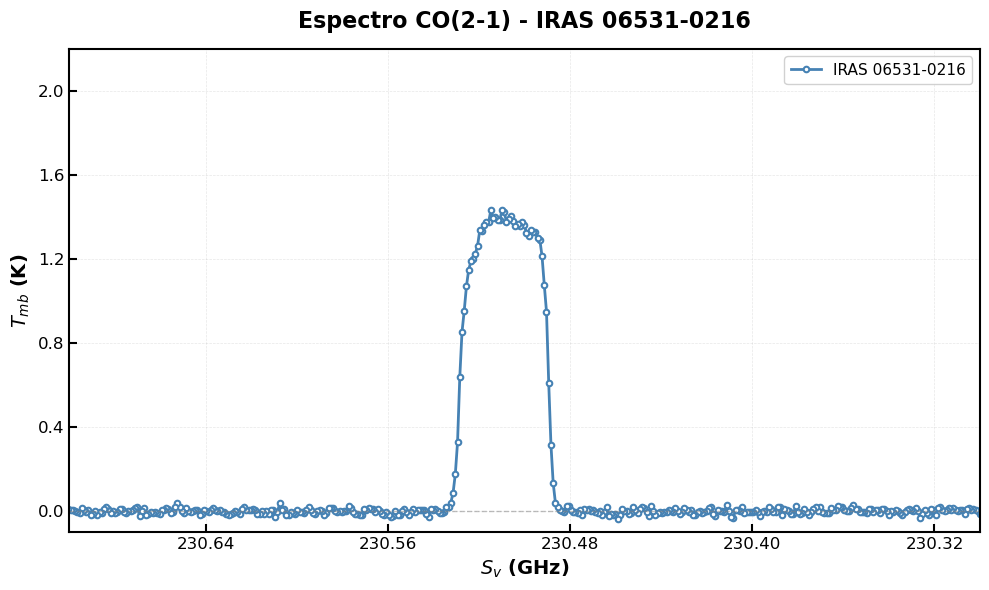

In [75]:
def convert_T_mb(data, limit):
    theta_maj = (1.809633214088E-03) * (3600)                                                 
    theta_min = (1.284642819447E-03) * (3600)
    x_max, x_min = limit    
    x = data["col1"]
    y = data["col2"]
    
    mask = (x >= x_min) & (x <= x_max)
    indices_in_range = np.where(mask)[0]
    
    T_mb = 1.222*(10**6)*(y/((x**2) * theta_maj * theta_min))
    return {
        'col1': x, 
        'T_mb': T_mb
    }


T_mb_IRAS_06531_2to1 = convert_T_mb(IRAS_06531_231, lim_CO_2to1_IRAS_06531_231)


fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(T_mb_IRAS_06531_2to1["col1"], T_mb_IRAS_06531_2to1["T_mb"], 
        'o-', linewidth=2, markersize=4, color='steelblue', 
        markerfacecolor='white', markeredgewidth=1.5,
        label='IRAS 06531-0216')

ax.set_xlim(lim_CO_2to1_IRAS_06531_231)

ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

ax.set_xlabel(r'$S_v$ (GHz)', fontsize=14, fontweight='bold')
ax.set_ylabel(r'$T_{mb}$ (K)', fontsize=14, fontweight='bold')

ax.set_title('Espectro CO(2-1) - IRAS 06531-0216', 
             fontsize=16, fontweight='bold', pad=15)

ax.set_xlim(lim_CO_2to1_IRAS_06531_231)
ax.set_ylim(-0.10, 2.2)
ax.xaxis.set_major_locator(MaxNLocator(6))
ax.yaxis.set_major_locator(MaxNLocator(6))
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.legend(loc='best', fontsize=11, framealpha=0.9)
ax.tick_params(axis='both', which='major', labelsize=12, 
               direction='in', length=6, width=1.5)
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=1)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()


In [76]:
def freq_to_velocity(freq, freq_rest, convention='radio'):
    """
    - CO(1-0): 115.271 GHz
    - CO(2-1): 230.538 GHz
    - CO(3-2): 345.796 GHz

    """
    c = const.c.to('km/s').value  # Velocidad de la luz en km/s
    
    if convention == 'radio':
        # Definicion radio (la mas usada en radioastronomia)
        velocity = c * (freq_rest - freq) / freq_rest

    else:
        raise ValueError("Revisar eeeee")
    
    return velocity


def convert_data_to_velocity(data, freq_rest, convention='radio'):

    from copy import deepcopy
    
    data_vel = deepcopy(data)
    
    # Convertir frecuencia a velocidad
    freq_ghz = np.array(data_vel["col1"])
    velocity = freq_to_velocity(freq_ghz, freq_rest, convention)
    
    # Reemplazar col1 con velocidad
    data_vel["col1"] = velocity
    
    return data_vel


# Frecuencia de reposo de CO(2-1)
freq_rest_CO10 = 230.538  # GHz

data_vel_2 = {}
for name, table in data.items():
    data_vel_2[name] = convert_data_to_velocity(table, freq_rest_CO10, convention='radio')

Parametros iniciales:
  T_peak ~ 1.434 K
  V_c    ~ 30.169 km/s
  V_e    ~ 24.129 km/s
  beta   ~ 0.40

RESULTADOS DEL AJUSTE:
T_mb^peak = 1.411 ± 0.007 K
V_c       = 37.804  ± 0.029 km/s
V_e       = 25.550  ± 0.047 km/s
R^2       = 0.9933


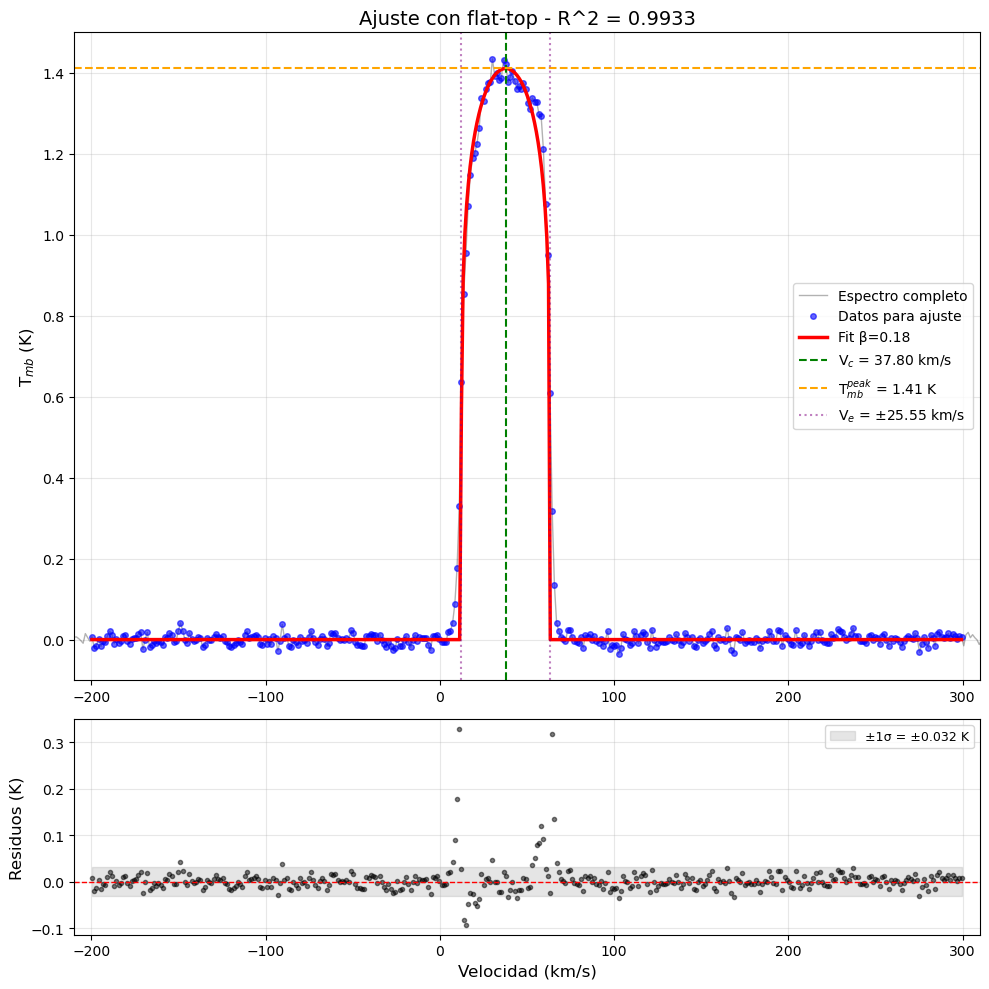

In [77]:
def flat_top_profile(v, T_peak, V_c, V_e, beta):
    
    term = ((v - V_c) / V_e)**2
    result = np.zeros_like(v, dtype=float)
    mask = term <= 1
    result[mask] = T_peak * (1 - term[mask])**beta
    return result


def fit_line_profile(data, data_1, v_limits, plot=True):

    v_min, v_max = v_limits
    
    v = np.array(data["col1"])
    T_mb_IRAS_06531 = convert_T_mb(data_1, lim_CO_2to1_IRAS_06531_231)
    T_mb = T_mb_IRAS_06531["T_mb"]
    
    mask = (v >= v_min) & (v <= v_max)
    v_fit = v[mask]
    T_fit = T_mb[mask]
    
    T_peak_guess = np.max(T_fit)
    idx_max = np.argmax(T_fit)
    V_c_guess = v_fit[idx_max]
    
    half_max = T_peak_guess / 2
    above_half = T_fit > half_max
    if np.sum(above_half) > 1:
        v_half_range = v_fit[above_half]
        V_e_guess = (v_half_range.max() - v_half_range.min()) / 2
    else:
        V_e_guess = (v_max - v_min) / 4
    
    V_e_guess = max(abs(V_e_guess), 1.0)
    beta_guess = 0.4  # <-- empieza con techo plano, la parabola clasica es 1.0
    
    p0 = [T_peak_guess, V_c_guess, V_e_guess, beta_guess]
    
    bounds = (
        [0,           v_min, 1,   0.1],   # beta minimo 0.1
        [T_peak_guess*2, v_max, (v_max-v_min), 2.0]  # beta maximo 2.0
    )
    
    print(f"Parametros iniciales:")
    print(f"  T_peak ~ {T_peak_guess:.3f} K")
    print(f"  V_c    ~ {V_c_guess:.3f} km/s")
    print(f"  V_e    ~ {V_e_guess:.3f} km/s")
    print(f"  beta   ~ {beta_guess:.2f}")
    
    try:
        popt, pcov = curve_fit(
            flat_top_profile,
            v_fit,
            T_fit,
            p0=p0,
            bounds=bounds,
            maxfev=10000
        )
        
        T_peak_fit, V_c_fit, V_e_fit, beta_fit = popt
        perr = np.sqrt(np.diag(pcov))
        
        T_model_fit = flat_top_profile(v_fit, *popt)
        residuals = T_fit - T_model_fit
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((T_fit - np.mean(T_fit))**2)
        r_squared = 1 - (ss_res / ss_tot)
        
        print(f"\n{'='*50}")
        print(f"RESULTADOS DEL AJUSTE:")
        print(f"{'='*50}")
        print(f"T_mb^peak = {T_peak_fit:.3f} ± {perr[0]:.3f} K")
        print(f"V_c       = {V_c_fit:.3f}  ± {perr[1]:.3f} km/s")
        print(f"V_e       = {V_e_fit:.3f}  ± {perr[2]:.3f} km/s")
        print(f"R^2       = {r_squared:.4f}")
        print(f"{'='*50}")
        
        if plot:
            v_model = np.linspace(v_fit.min(), v_fit.max(), 500)
            T_model = flat_top_profile(v_model, *popt)
            
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10),
                                           gridspec_kw={'height_ratios': [3, 1]})

            ax1.plot(v, T_mb, 'k-', alpha=0.3, label='Espectro completo', linewidth=1)
            ax1.plot(v_fit, T_fit, 'bo', markersize=4, label='Datos para ajuste', alpha=0.6)
            ax1.plot(v_model, T_model, 'r-', linewidth=2.5,
                     label=f'Fit β={beta_fit:.2f}')

            ax1.axvline(V_c_fit, color='green', linestyle='--', linewidth=1.5,
                        label=f'V$_c$ = {V_c_fit:.2f} km/s')
            ax1.axhline(T_peak_fit, color='orange', linestyle='--', linewidth=1.5,
                        label=f'T$_{{mb}}^{{peak}}$ = {T_peak_fit:.2f} K')
            ax1.axvline(V_c_fit - V_e_fit, color='purple', linestyle=':', alpha=0.5, linewidth=1.5)
            ax1.axvline(V_c_fit + V_e_fit, color='purple', linestyle=':', alpha=0.5, linewidth=1.5,
                        label=f'V$_e$ = ±{V_e_fit:.2f} km/s')

            ax1.set_ylabel('T$_{mb}$ (K)', fontsize=12)
            ax1.set_title(f'Ajuste con flat-top - R^2 = {r_squared:.4f}', fontsize=14)
            ax1.legend(loc='best', fontsize=10)
            ax1.grid(True, alpha=0.3)
            ax1.set_xlim([v_min - 10, v_max + 10])
            ax1.set_ylim(-0.10, 1.5)

            ax2.plot(v_fit, residuals, 'ko', markersize=3, alpha=0.5)
            ax2.axhline(0, color='red', linestyle='--', linewidth=1)
            ax2.fill_between(v_fit, -np.std(residuals), np.std(residuals),
                             alpha=0.2, color='gray',
                             label=f'±1σ = ±{np.std(residuals):.3f} K')
            ax2.set_xlabel('Velocidad (km/s)', fontsize=12)
            ax2.set_ylabel('Residuos (K)', fontsize=12)
            ax2.legend(loc='best', fontsize=9)
            ax2.grid(True, alpha=0.3)
            ax2.set_xlim([v_min - 10, v_max + 10])

            plt.tight_layout()
            plt.show()

        return {
            'T_peak': T_peak_fit,
            'V_c': V_c_fit,
            'V_e': V_e_fit,
            'beta': beta_fit,
            'errors': perr,
            'r_squared': r_squared,
            'popt': popt,
            'pcov': pcov
        }

    except Exception as e:
        print(f"ERROR en el ajuste: {e}")
        return None

v_limits = (-200, 300)  # Aaustar esto donde se vean los limites en general se puede ver en el paper jeje
T_mb_fit_2to1 = fit_line_profile(data_vel_2['IRAS_06531_231'], IRAS_06531_231 , v_limits, plot=True)

In [78]:
############# Mass Loss Rate ############################
### De CO(2-1)


W = result['W'] 
T_mb_peak, V_exp = T_mb_fit_2to1["T_peak"], T_mb_fit_2to1["V_e"] # K , # km/s 
D = 1158.35  # distancia pc

BMAJ_deg = 1.809633214088E-03 # grados
BMIN_deg = 1.284642819447E-03 # grados

BMAJ_arcsec = BMAJ_deg * 3600.0 # arcsec
BMIN_arcsec = BMIN_deg * 3600.0 # arcsec
theta_arcsec = np.sqrt(BMAJ_arcsec * BMIN_arcsec)  # media arcsec NOTA:preguntar si calcular la media es correcto o calculo con el FWHM

s_J   = 0.6    # factor de correccion para la transicion J ---> 2-1
f_CO  = 1e-3   # abundancia CO/H2 para IRAS 06531 NOTA: el valor fue asumido desde (Zuckerman & Dyck 1986)al igual que lo hizo (S. Ramstedt et al. 2008)


log_term  = np.log10(W / 0.04)
T_term    = T_mb_peak / (log_term * s_J)
Dtheta    = D * theta_arcsec  # pc * arcsec

M_dot = (4.55e-19
         * (T_term ** (5/6))
         * (f_CO ** (-1))
         * (V_exp ** (11/6))
         * (Dtheta ** (5/3)))


### Caso de opticamnete grue

numerador   = 1.4 * T_mb_peak * (V_exp**2) * (D**2) * (theta_arcsec**2)
denominador = 2e19 * (f_CO**0.85) * s_J

M_dot_thick = numerador / denominador

# --- Resultados ---
print(f"\n{'='*55}")
print(f"  MASS LOSS RATE - IRAS 06531-0216  |  CO(2-1)")
print(f"{'='*55}")
print(f"  Parametros:")
print(f"    W              = {W:.4f}")
print(f"    log10(W/0.04)  = {log_term:.4f}")
print(f"    T_mb peak      = {T_mb_peak:.4f} K")
print(f"    V_exp          = {V_exp:.2f} km/s")
print(f"    D              = {D:.2f} pc")
print(f"    BMAJ           = {BMAJ_arcsec:.4f} arcsec")
print(f"    BMIN           = {BMIN_arcsec:.4f} arcsec")
print(f"    theta (geom.)  = {theta_arcsec:.4f} arcsec")
print(f"    D * theta      = {Dtheta:.2f} pc·arcsec")
print(f"    s(J)           = {s_J}")
print(f"    f_CO           = {f_CO:.1e}")
print(f"")
print(f"  RESULTADO:")
print(f"    Mdot = {M_dot:.4e} M_sun/yr")
print(f"    Mdot_thick = {M_dot_thick:.4e} M_sun/yr")
print(f"{'='*55}")


  MASS LOSS RATE - IRAS 06531-0216  |  CO(2-1)
  Parametros:
    W              = 0.7572
    log10(W/0.04)  = 1.2772
    T_mb peak      = 1.4107 K
    V_exp          = 25.55 km/s
    D              = 1158.35 pc
    BMAJ           = 6.5147 arcsec
    BMIN           = 4.6247 arcsec
    theta (geom.)  = 5.4889 arcsec
    D * theta      = 6358.12 pc·arcsec
    s(J)           = 0.6
    f_CO           = 1.0e-03

  RESULTADO:
    Mdot = 6.2805e-07 M_sun/yr
    Mdot_thick = 1.5411e-06 M_sun/yr


$\Huge CO(2-1)$
  
    Mdot = 6.2805e-07 M_sun/yr
    Mdot_thick = 1.5411e-06 M_sun/yr

$\Huge CO(1-0)$

    Mdot = 5.1848e-07 M_sun/yr
    Mdot_thick = 1.2139e-06 M_sun/yr


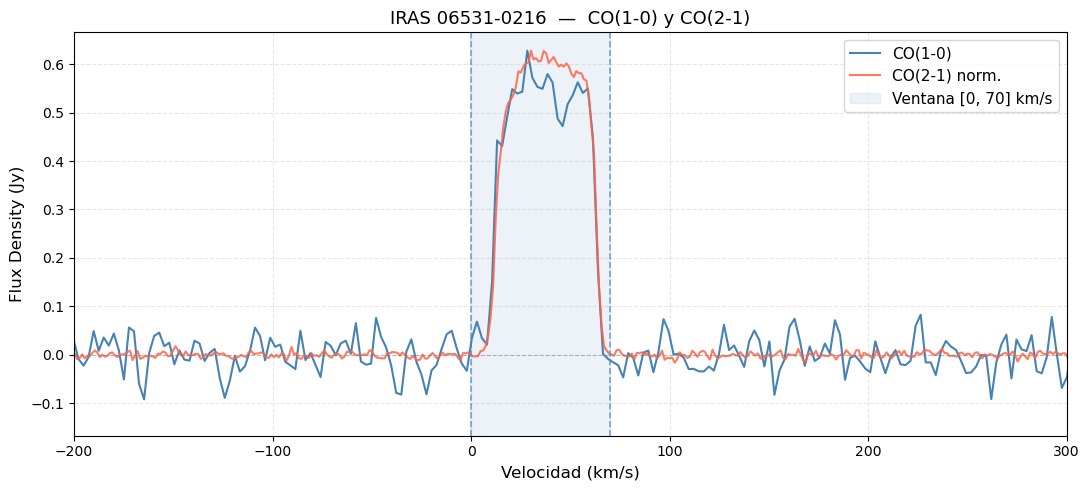


  LINE FLUX RATIO IRAS 06531-0216 CO(2-1) / CO(1-0)
  Ventana : [0, 70] km/s
  CO(1-0) = 27.9920 Jy·km/s
  CO(2-1) = 87.8595 Jy·km/s
  Ratio R(2-1)/(1-0) = 3.1387


In [79]:
v_min = 0   # km/s
v_max = 70   # km/s


c_kms = const.c.to('km/s').value
freq_rest_CO10 = 115.271  # GHz
freq_rest_CO21 = 230.538  # GHz

vel_10  = np.array(data_vel['IRAS_06531_115']['col1'])
flux_10 = np.array(data_vel['IRAS_06531_115']['col2'])
vel_21  = np.array(data_vel_2['IRAS_06531_231']['col1'])
flux_21 = np.array(data_vel_2['IRAS_06531_231']['col2'])


norm_21 = flux_21 * (np.nanmax(flux_10) / np.nanmax(flux_21))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(vel_10, flux_10, color='steelblue', lw=1.5, label='CO(1-0)')
ax.plot(vel_21, norm_21, color='tomato',    lw=1.5, label='CO(2-1) norm.', alpha=0.85)
ax.axvspan(v_min, v_max, color='steelblue', alpha=0.10, label=f'Ventana [{v_min}, {v_max}] km/s')
ax.axvline(v_min, color='steelblue', lw=1.2, ls='--', alpha=0.7)
ax.axvline(v_max, color='steelblue', lw=1.2, ls='--', alpha=0.7)
ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.5)
ax.set_xlim(-200, 300)
ax.set_xlabel('Velocidad (km/s)', fontsize=12)
ax.set_ylabel('Flux Density (Jy)', fontsize=12)
ax.set_title('IRAS 06531-0216  —  CO(1-0) y CO(2-1)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, ls='--')
plt.tight_layout()
plt.show()

m10 = (vel_10 >= v_min) & (vel_10 <= v_max)
m21 = (vel_21 >= v_min) & (vel_21 <= v_max)

I10 = np.abs(np.trapezoid(np.maximum(flux_10[m10], 0), vel_10[m10]))
I21 = np.abs(np.trapezoid(np.maximum(flux_21[m21], 0), vel_21[m21]))
R   = I21 / I10

print(f"\n{'='*50}")
print(f"  LINE FLUX RATIO IRAS 06531-0216 CO(2-1) / CO(1-0)")
print(f"{'='*50}")
print(f"  Ventana : [{v_min}, {v_max}] km/s")
print(f"  CO(1-0) = {I10:.4f} Jy·km/s")
print(f"  CO(2-1) = {I21:.4f} Jy·km/s")
print(f"  Ratio R(2-1)/(1-0) = {R:.4f}")
print(f"{'='*50}")

In [109]:
def freq_to_velocity(freq, freq_rest, convention='radio'):
    """
    - CO(1-0): 115.271 GHz
    - CO(2-1): 230.538 GHz
    - CO(3-2): 345.796 GHz

    """
    c = const.c.to('km/s').value  # Velocidad de la luz en km/s
    
    if convention == 'radio':
        # Definicion radio (la mas usada en radioastronomia)
        velocity = c * (freq_rest - freq) / freq_rest

    else:
        raise ValueError("Revisar eeeee")
    
    return velocity


def convert_data_to_velocity(data, freq_rest, convention='radio'):

    from copy import deepcopy
    
    data_vel = deepcopy(data)
    
    # Convertir frecuencia a velocidad
    freq_ghz = np.array(data_vel["col1"])
    velocity = freq_to_velocity(freq_ghz, freq_rest, convention)
    
    # Reemplazar col1 con velocidad
    data_vel["col1"] = velocity
    
    return data_vel


# Frecuencia de reposo de 13CO(2-1)
freq_rest_CO10 = 220.39868  # GHz

data_vel_3 = {}
for name, table in data.items():
    data_vel_3[name] = convert_data_to_velocity(table, freq_rest_CO10, convention='radio')


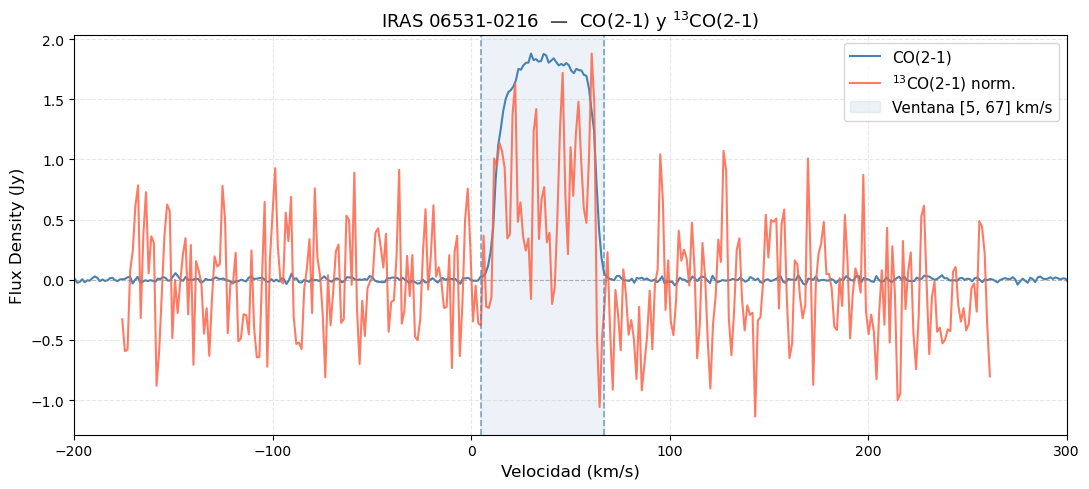


  LINE FLUX RATIO IRAS 06531-0216 CO(2-1) / 13CO(2-1)
  Ventana : [5, 67] km/s
  CO(2-1) = 87.7380 Jy·km/s
  13CO(2-1) = 1.0361 Jy·km/s
  Ratio R (2-1) / 13(2-1) = 84.6838


In [127]:
v_min = 5   # km/s
v_max = 67   # km/s


c_kms = const.c.to('km/s').value
freq_rest_CO10 = 230.538  # GHz
freq_rest_13CO10 = 110.201  # GHz

vel_10  = np.array(data_vel_2['IRAS_06531_231']['col1'])
flux_10 = np.array(data_vel_2['IRAS_06531_231']['col2'])
vel_3_10  = np.array(data_vel_3['IRAS_06531_220']['col1'])
flux_3_10 = np.array(data_vel_3['IRAS_06531_220']['col2'])


norm_21 = flux_3_10 * (np.nanmax(flux_10) / np.nanmax(flux_3_10))


fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(vel_10, flux_10, color='steelblue', lw=1.5, label='CO(2-1)')
ax.plot(vel_3_10, norm_21, color='tomato',    lw=1.5, label=r'$^{13}$CO(2-1) norm.', alpha=0.85)
ax.axvspan(v_min, v_max, color='steelblue', alpha=0.10, label=f'Ventana [{v_min}, {v_max}] km/s')
ax.axvline(v_min, color='steelblue', lw=1.2, ls='--', alpha=0.7)
ax.axvline(v_max, color='steelblue', lw=1.2, ls='--', alpha=0.7)
ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.5)
ax.set_xlim(-200, 300)
ax.set_xlabel('Velocidad (km/s)', fontsize=12)
ax.set_ylabel('Flux Density (Jy)', fontsize=12)
ax.set_title('IRAS 06531-0216  —  CO(2-1) y $^{13}$CO(2-1)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, ls='--')
plt.tight_layout()
plt.show()

m10 = (vel_10 >= v_min) & (vel_10 <= v_max)
m21 = (vel_3_10 >= v_min) & (vel_3_10 <= v_max)

I10 = np.abs(np.trapezoid(np.maximum(flux_10[m10], 0), vel_10[m10]))
I21 = np.abs(np.trapezoid(np.maximum(flux_3_10[m21], 0), vel_3_10[m21]))
R   = I10 / I21

print(f"\n{'='*50}")
print(rf"  LINE FLUX RATIO IRAS 06531-0216 CO(2-1) / 13CO(2-1)")
print(f"{'='*50}")
print(f"  Ventana : [{v_min}, {v_max}] km/s")
print(f"  CO(2-1) = {I10:.4f} Jy·km/s")
print(f"  13CO(2-1) = {I21:.4f} Jy·km/s")
print(f"  Ratio R (2-1) / 13(2-1) = {R:.4f}")
print(f"{'='*50}")